In [1]:
import pandas as pd
import numpy as np
from wavelets1 import GridWaveletTransform
import matplotlib.pyplot as plt


In [2]:
duration = 100; sampleRate = 50; N = duration*sampleRate; T = 1/sampleRate
samples = np.linspace(0, duration, N, endpoint=False)
signals = np.zeros((5, samples.shape[0]))

"Import ambient magnetic field signal."
df=pd.read_csv(r'Swarm_MAGA_HR_20150317_0900.csv', sep=',',header=None)
r = df[10]
swarm = np.array([np.fromstring(r[i][1:-1], dtype=float, sep=' ') for i in range(1, r.shape[0])]).T[:,160000:160000+N]
data =swarm[0]

C:\Users\aphoffm2\AppData\Local\Temp\1\ipykernel_2576\2232759324.py:6: DtypeWarning: Columns (2,5,6,8,9) have mixed types. Specify dtype option on import or set low_memory=False.
  df=pd.read_csv(r'Swarm_MAGA_HR_20150317_0900.csv', sep=',',header=None)


Reconstruction error: 52859.872172828116


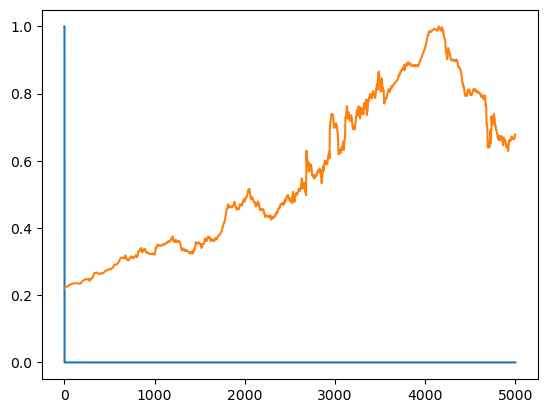

In [10]:
# Create a sample time-series: a sine wave for demonstration
sample_rate = 50.0          # 50 Hz sampling rate
num_samples = 5000          # 5000 samples
t = np.arange(num_samples) / sample_rate
#data = np.sin(2 * np.pi * 5 * t)  # A 5 Hz sine wave

# Define transform parameters
M = 128
M_C = 1
b = 2
q = 1# b*M_C
xi1 = sample_rate * q / (2 * M)
d = 1.0
kernel_size = 512

# Initialize the GridWaveletTransform
transform = GridWaveletTransform(
    fs = sample_rate,
    M=M,
    M_C=M_C,
    d=1,
)

# Perform forward wavelet transform
coefficients, meta = transform.transform(data)

# Perform inverse wavelet transform (reconstruction)
reconstructed = transform.inverse(coefficients, meta)

# Calculate and print reconstruction error
reconstruction_error = np.linalg.norm(reconstructed - data)
print(f"Reconstruction error: {reconstruction_error}")

# Optional: Plot grid decimation pattern
#transform.plot_grid_decimation()

# Optional: Plot scalogram
#transform.plot_scalogram(coefficients)
plt.plot(reconstructed/np.max(reconstructed))
plt.plot(data/np.max(data))

# Optional: Compute frame bounds
#A, B = transform.compute_frame_bounds()
#print(f"Frame bounds: A = {A}, B = {B}, Ratio B/A = {B/A}")


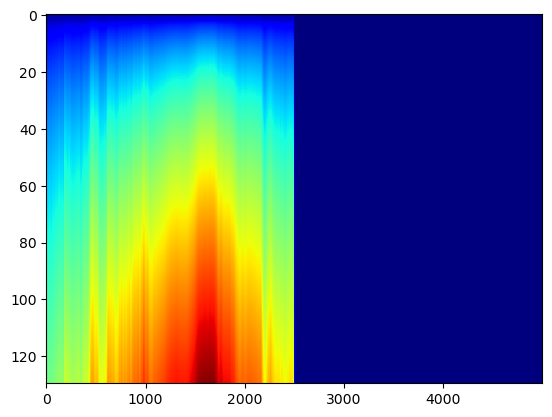

In [11]:
plt.imshow(np.abs(coefficients), aspect='auto', cmap='jet')

Reconstruction error: 3.6036175722099264


c:\Users\aphoffm2\AppData\Local\anaconda3\Lib\site-packages\matplotlib\cbook.py:1699: ComplexWarning: Casting complex values to real discards the imaginary part
  return math.isfinite(val)
c:\Users\aphoffm2\AppData\Local\anaconda3\Lib\site-packages\matplotlib\cbook.py:1345: ComplexWarning: Casting complex values to real discards the imaginary part
  return np.asarray(x, float)


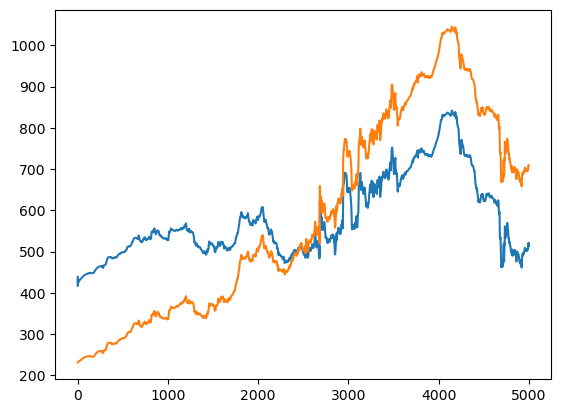

In [4]:
from wavelets import WaveletAnalysis as WA
w1 = WA(data, dt=T, dj=1/8, frequency=True, unbias=False, mask_coi = True)
wn1 = w1.wavelet_transform.real
W_n = wn1 
Y_00 = w1.wavelet.time(0)
s = w1.scales
r_sum = np.sum(W_n.real.T / s ** .5, axis=-1).T
amb_mf = r_sum * (1/8 * T ** .5 / (w1.C_d * Y_00))
amb_mf += w1.data.mean(axis=w1.axis, keepdims=True)
plt.plot(amb_mf)
plt.plot(swarm[0])
print("Reconstruction error:", np.sqrt(np.mean(data[100:-100] - amb_mf[100:-100].real)**2))

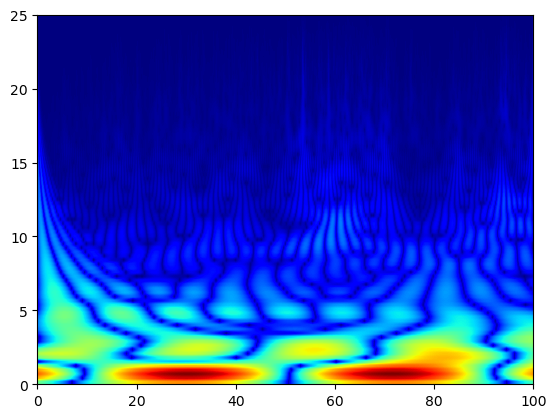

In [18]:
plt.imshow(np.abs(wn1)**.5, aspect='auto', extent=[0, duration, 0, 1/(2*T)], cmap='jet')